# Generate Sense Inventory

This notebook contains all the code to generate a sense inventory.

## Setup

In [49]:
# Uncomment if not yet installed

# !pip install -U transformers sentence_transformers numpy torch pandas scikit-learn matplotlib

In [50]:
DATA_DIR = r'..\data'
MODEL_DIR = r'..\models'
VALIDATION_DIR = r'..\data\PWN validation data'

In [51]:
from transformers import TFAutoModel, AutoModel, AutoTokenizer
import torch
import numpy as np
import pandas as pd
import random
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.manifold import TSNE
import json
import regex as re
from scipy.cluster.hierarchy import dendrogram
from matplotlib import pyplot as plt
import pickle

In [52]:
def get_example_sentences(COHFIE, target_word, n_sentences=None, frac=None, window=None, print_output=False):
    '''
    Returns a list of sentences that contains target_word

    Params:
        - COHFIE : df containing COHFIE entries;
        - target_word : str;
        - window: int; <window ... target_word ... window>
        - print_output: bool; print strings
    '''
    # Initialize empty list
    sentences = []

    # Sources
    sources = ['social_media', 'online_forums', 'news_sites', 'books']

    for source in sources:
      if frac is not None:
        COHFIE_sample = COHFIE.loc[(COHFIE['source_type']==source) & COHFIE['text'].str.contains(f" {target_word} ")].reset_index(drop=True) # space separated target word
        n_samples = COHFIE_sample.shape[0]
        n_sentences = int(n_samples * frac)
        print(f"{source}: {n_sentences}")
      elif n_sentences is not None and frac is None:
          COHFIE_sample = COHFIE.loc[(COHFIE['source_type']==source)].reset_index(drop=True)
      elif frac is not None and n_sentences != None:
          print("n_sentences must be set to None if you will use frac.")
          return

      sentence_list = COHFIE_sample['text']
      n = 0
    


      for i, sent in enumerate(sentence_list):
          
          if n == n_sentences: # early stop
              break
          
          sent_tokenized = sent.split(" ")
          if target_word in sent_tokenized:
              
              if n != n_sentences:
                n = n + 1 # increment sentence count per source

                # preprocessing
                sent_new = re.sub(r'(?<!\S)XX_[A-Za-z]*(?!\S)','', sent)
                sent_new = re.sub(r'\s\s+',' ', sent_new)
                sent_new = re.sub(r'^\s+','', sent_new)
                sent_new = re.sub(r'\s+$','', sent_new)
                sent_new_tokenized = sent_new.split(" ")

                pos_new_tokenized = COHFIE_sample['pos_tags'][i].split(" ")
                target_pos_index = sent_new_tokenized.index(target_word)
                target_word_index = sent_tokenized.index(target_word)

                if len(sent_new_tokenized) == len(pos_new_tokenized):
                  if window is not None:
                      sent_new = re.sub(r' ,', ',', sent_new)
                      sent_new = re.sub(r' !', '!', sent_new)
                      sent_new = re.sub(r' \?', '?', sent_new)
                      sent_new = re.sub(r'( \.\.\. | \.\.\.)', '', sent_new) # " ... " or " ..."
                      sent_new = re.sub(r'( \.)', '.', sent_new)
                      sent_new = re.sub(r'"', '', sent_new) # remove quotes
                      sent_new_tokenized = sent_new.split(" ")
                      low = max(0, target_word_index - window)
                      high = min(len(sent_new_tokenized), target_word_index + window + 1)
                      s = " ".join(sent_new_tokenized[low:high])
                  else:
                      s = " ".join(sent_new_tokenized)
            
                  # Include year where the example sentence is from
                  sentences.append([s, pos_new_tokenized[target_pos_index], COHFIE_sample['lang'][i], COHFIE_sample['source'][i], COHFIE_sample['source_type'][i], COHFIE_sample['year'][i], COHFIE_sample['month'][i]])

                  if print_output:
                      print(s)
                    
                  # clean up
                  del sent_new
                  del sent_tokenized
                  del sent_new_tokenized
                  del pos_new_tokenized
                  del s

    return np.array(sentences)

def get_embeddings(model, sentence_list):
    sentence_list_texts = sentence_list[:, :1].squeeze().tolist()
    sentence_list_pos = sentence_list[:, 1:2].squeeze().tolist()
    sentence_list_lang = sentence_list[:, 2:3].squeeze().tolist()
    sentence_list_source = sentence_list[:, 3:4].squeeze().tolist()
    sentence_list_source_type = sentence_list[:, 4:5].squeeze().tolist()
    sentence_list_year = sentence_list[:, 5:6].squeeze().tolist()
    sentence_list_month = sentence_list[:, 6:7].squeeze().tolist()

    sentence_embeddings = model.encode(sentence_list_texts, show_progress_bar=False, normalize_embeddings=True)
    

    # Create dataframe
    df = pd.DataFrame(data={'text': sentence_list_texts, 'pos': sentence_list_pos, 'lang': sentence_list_lang, 'source': sentence_list_source, 'source_type': sentence_list_source_type,  'year': sentence_list_year, 'month': sentence_list_month})
    df['embs'] = pd.Series(list(sentence_embeddings), index=df.index)

    # DROP DUPLICATES
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

    return df

def get_mean_embeddings(df_clustered):
    # get cluster labels 0, 1, ..., n
    cluster_labels = sorted(df_clustered["cluster"].unique())

    embs_mean = []

    # Average the sentence embeddings per cluster
    for label in cluster_labels:
        embs = df_clustered.loc[df_clustered["cluster"]==label].embs.mean()
        embs_mean.append(embs)

    return np.array(embs_mean)

def trim_cluster(df_clustered, centroids, trim_cluster_max_size, debug=False):
    mask = [] # contains all indexes to keep
    cluster_labels = sorted(df_clustered['cluster'].unique()) # 0 1 2 ... n_clusters
    
    if debug:
        print(f"Trimming {len(cluster_labels)} clusters")


    for i in cluster_labels:
        current_centroid = centroids[i] # centroid of current cluster
        df_cluster_members = df_clustered[df_clustered['cluster'] == i]
        cluster_members_embs = list(df_cluster_members['embs'])

        # looking only at one sense
        trim_cluster_max_size = trim_cluster_max_size
        cos = torch.nn.CosineSimilarity(dim=1, eps=1e-08)
        similarity_scores = cos(torch.tensor(cluster_members_embs), torch.tensor(list(current_centroid)).unsqueeze(0))
        n_keep = min(trim_cluster_max_size, len(similarity_scores))
        idx_to_keep = torch.topk(similarity_scores,n_keep)[1].tolist() # iloc indexes ito, not actual index sa dataframe
        idx_to_keep = df_cluster_members.iloc[idx_to_keep].index.tolist()
        mask +=  idx_to_keep

    # Keep only nearest neighbors of centroid
    df_clustered = df_clustered.loc[mask]

    return df_clustered
    
def cluster_sents(df_text_embs, mode="AP", mode_args={}, random_state=0, purge_weak_clusters=False, weak_clusters_threshold=None, trim_clusters=False, trim_cluster_max_size=None, debug=False):
    '''
        df_text_embs: columns=['text', 'embs']
            text: sentence string
            embs: sentence_embeddings
    '''
    ##############################
    # ERROR CHECKING
    ##############################
    if bool(mode_args) == False: # False means empty dict
        print("mode_args dict is empty.")
        print("Must specify mode_args = dict (e.g. mode_args = {'n_clusters': 3}")
        return
    if trim_clusters == True and trim_cluster_max_size is None:
        print("trim_clusters is True but trim_cluster_max_size is None.")
        print("Either set trim_clusters to False or set trim_cluster_max_size to some value.")
        return
    if trim_clusters == False and trim_cluster_max_size is not None:
        print("trim_clusters is False but trim_cluster_max_size is not None.")
        print("Either set trim_clusters to True or set trim_cluster_max_size to None.")
        return
    if purge_weak_clusters == True and weak_clusters_threshold is None:
        print("purge_weak_clusters is True but weak_clusters_threshold is None.")
        print("Either set purge_weak_clusters to False or set weak_clusters_threshold to some value.")
        return
    if purge_weak_clusters == False and weak_clusters_threshold is not None:
        print("purge_weak_clusters is False but weak_clusters_threshold is not None.")
        print("Either set purge_weak_clusters to True or set weak_clusters_threshold to None.")
        return
    # if mode != "KMEANS" and search_n_clusters == True:
    #     print("mode is NOT 'KMEANS' but search_n_clusters is True.")
    #     print("search_n_clusters only works with KMEANS.")
    #     return


    if debug:
        print("cluster_sents():")
        print(f"    mode: {mode}")
        print(f"    mode_args: {mode_args}")


    ##############################
    # CLUSTERING
    ##############################
    embeddings = list(df_text_embs['embs'])
    df_clustered = df_text_embs.copy()

    if mode == "KMEANS":
        if 'n_clusters' not in mode_args:
            print("KMEANS clustering requires n_clusters in mode_args.")
            return
        if isinstance(mode_args['n_clusters'], int):
            n_clusters = mode_args['n_clusters']
        else:
            print("n_clusters should be an integer.")
            return

        # clustering proper
        kmeans = KMeans(n_clusters=n_clusters, 
                        random_state=random_state, 
                        n_init=10).fit(embeddings)

        df_clustered['cluster'] = kmeans.labels_
        centroids = kmeans.cluster_centers_

    elif mode == "AP":
        if 'damping' not in mode_args:
            print("AP clustering requires damping in mode_args.")
            return
        if isinstance(mode_args['damping'], float):
            damping = mode_args['damping']
        else:
            print("n_clusters should be a float.")
            return

        
        # Set default hyperparameters
        max_iter = 1000
        convergence_iter = 50

        # clustering proper
        af = AffinityPropagation(damping=damping, 
                                 max_iter=max_iter, 
                                 convergence_iter=convergence_iter,
                                 random_state=random_state).fit(embeddings)

        df_clustered['cluster'] = af.labels_
        centroids = get_mean_embeddings(df_clustered)

    elif mode == "AG":
        if 'n_clusters' not in mode_args:
            print("AG clustering requires n_clusters to be either None or integer.")
            return

        if isinstance(mode_args['n_clusters'], int): # manual setting of n_clusters
            print("AG MANUAL")
            n_clusters = mode_args['n_clusters']
            distance_threshold = None
        elif mode_args['n_clusters'] is None: # automatic induction of n_clusters
            print("AG AUTO")
            n_clusters = None
            if 'distance_threshold' in mode_args:
                distance_threshold = mode_args['distance_threshold']
            else:
                print("If n_clusters is None, you must specify distance_threshold in mode_args.")
                return

        # Set default hyperparameters
        affinity = "cosine"
        linkage = "average"

        # clustering proper
        AG = AgglomerativeClustering(n_clusters=n_clusters, 
                                     affinity=affinity, 
                                     linkage=linkage, 
                                     distance_threshold=distance_threshold,
                                     compute_distances=True).fit(embeddings)

        df_clustered['cluster'] = AG.labels_
        centroids = get_mean_embeddings(df_clustered)
        plt.clf()
        plot_dendrogram(AG)
        plt.show()


    if debug:
        print(f"    centroids shape: {centroids.shape}")

    ##############################
    # PURGE WEAK CLUSTERS
    ##############################
    if purge_weak_clusters and centroids is not None: # only works if multiple clusters
        cluster_members_counts = df_clustered.groupby(by='cluster').count()
        weak_clusters = cluster_members_counts[cluster_members_counts['text'] <= weak_clusters_threshold].index.to_list()
        n_weak_clusters = len(weak_clusters)
        
        if n_weak_clusters != 0:
            print(f'Found {n_weak_clusters} weak clusters. Purging...')
            to_drop = df_clustered[df_clustered['cluster'].isin(weak_clusters)].index
            df_clustered = df_clustered.drop(to_drop).reset_index(drop=True)

            mask = np.ones(len(centroids), dtype=bool)
            mask[weak_clusters] = False
            centroids = centroids[mask,...]


            # Adjust cluster labels
            for i, label in enumerate(np.sort(df_clustered['cluster'].unique())):
                df_clustered.loc[df_clustered['cluster'] == label, 'cluster'] = i
    
    ##############################
    # TRIM CLUSTERS
    ##############################
    if trim_clusters:
        # # Keep only nearest neighbors of centroid
        df_clustered = trim_cluster(df_clustered, centroids, trim_cluster_max_size, debug=debug)

        # recompute centroids
        print("recomputing centroids for trimmed cluster...")
        centroids = get_mean_embeddings(df_clustered)

        if debug:
            print("=== TRIM CLUSTER RESULTS ===")
            print(f"centroids shape: {centroids.shape}")
            display(df_clustered)



    return df_clustered, centroids

# Generate sense embeddings at a word level
def generate_sense_embeddings(sense_cluster_df, cluster_col="cluster"):
    senses = {}
    cluster_labels = sorted(sense_cluster_df[cluster_col].unique())
    
    # Average embeddings per cluster
    for label in cluster_labels:
        sense_embedding = torch.tensor(sense_cluster_df.loc[sense_cluster_df[cluster_col]==label].embs.mean()).unsqueeze(dim=0)
        sentence_lst = list(sense_cluster_df.loc[sense_cluster_df[cluster_col]==label].text)

        context_dict = []
        context_dict.append(list(sense_cluster_df.loc[sense_cluster_df[cluster_col]==label].year))
        context_dict.append(list(sense_cluster_df.loc[sense_cluster_df[cluster_col]==label].source))
        pos = list(sense_cluster_df.loc[sense_cluster_df[cluster_col]==label].pos)
        pos = max(set(pos), key=pos.count)

        contextual_lst = {}
        for i in range(len(context_dict[0])):
          if context_dict[1][i] in contextual_lst:
            if context_dict[0][i] in contextual_lst[context_dict[1][i]]:
              contextual_lst[context_dict[1][i]][context_dict[0][i]] += 1
            else:
              contextual_lst[context_dict[1][i]][context_dict[0][i]] = 1

          else:
            contextual_lst[context_dict[1][i]] = {context_dict[0][i]: 1}


        senses[label]  = {'sense_embedding': sense_embedding, 'example_sentences': sentence_lst, 'contextual_info':contextual_lst, 'pos': pos}
        
    return senses


def cluster_sense_embeddings(df_sense_embeddings, n_clusters=None, mode="KMEANS", random_state=0):
    '''
        df_sense_embeddings: columns=['word', 'sense_id', 'example_sentences', 'pos', 'contextual_info', 'sense_embedding']
    '''
    df_sense_clusters = pd.DataFrame(columns=['word', 'sense', 'synset_id'])
    df_sense_clusters['word'] = df_sense_embeddings['word']
    df_sense_clusters['sense'] = df_sense_embeddings['example_sentences']
    df_sense_clusters['contextual_info'] = df_sense_embeddings['contextual_info']
    df_sense_clusters['pos'] = df_sense_embeddings['pos']
    df_sense_clusters['sense_embedding'] = df_sense_embeddings['sense_embedding']

    sense_embeddings = list(df_sense_embeddings['sense_embedding'])
    if mode == "KMEANS":
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state).fit(sense_embeddings)
        df_sense_clusters['synset_id'] = kmeans.labels_
    elif mode == "AP":
        af = AffinityPropagation().fit(sense_embeddings)
        df_sense_clusters['synset_id'] = af.labels_
    elif mode == "GMM":
        gmm = GaussianMixture.fit(sense_embeddings)
        gmm_labels = gmm.predict(sense_embeddings)
        df_sense_clusters['synset_id'] = gmm_labels
        

    return df_sense_clusters

def merge(df_clustered, args):
    df_clustered_temp = df_clustered.copy()

    # Cluster centroids
    df_merged, centroids = cluster_sents(df_text_embs=args["df_text_embs"],
                                        mode=args["mode"],
                                        mode_args=args["mode_args"], 
                                        random_state=args["random_state"],
                                        purge_weak_clusters=args["purge_weak_clusters"], 
                                        weak_clusters_threshold=args["weak_clusters_threshold"],
                                        trim_clusters=False, # For merging, should be set to False
                                        trim_cluster_max_size=None, # For merging, should be set to None
                                        debug=args["debug"])
    
    
    # Mapping old cluster labels to new cluster labels
    df_clustered_temp['cluster_new'] = 0
    for idx, row in df_merged.iterrows():
        cluster_label_old = row['cluster_old']
        cluster_label_new = row['cluster']
        df_clustered_temp.loc[df_clustered_temp['cluster'] == cluster_label_old, 'cluster_new'] = cluster_label_new
    
    # Rename column (para standard for all)
    df_clustered_temp['cluster'] = df_clustered_temp['cluster_new']
    df_clustered_temp.drop("cluster_new", axis=1, inplace=True)

    if args["trim_clusters"] == True:
        df_clustered_temp = trim_cluster(df_clustered_temp, centroids, trim_cluster_max_size=args["trim_cluster_max_size"])

    return df_clustered_temp, centroids

def print_word_senes(df_senses):
    cluster_labels = sorted(df_senses["cluster"].unique())
    for idx, label in enumerate(cluster_labels):
        print(f"cluster {label} ({df_senses.loc[df_senses['cluster']==label].shape})")

        display(df_senses.loc[df_senses['cluster']==label])

def print_sense_inventory(sense_inventory):
    for idx, row in sense_inventory.iterrows():
        print(f"Sense id: {row['sense_id']}")
        for sentence in row['example_sentences']:
            print(f"    {sentence}")

In [53]:
def generate_sense_inventory(corpus, words, n_sentences=None, frac=None, window=None, random_state=0, debug=False, logs=False):    
    ##################################
    # HISTORY VARIABLES
    ##################################
    if logs:        
        cols = ['Word',
                'Window_size',
                'N_sentences',
                'Silhouette_score_step1',
                'Silhouette_score_step2',
                'Silhouette_score_step3',
                'Silhouette_score_step4',
                'Silhouette_score_step5',
                'Silhouette_score_step6',
                'Silhouette_score_step7',
                'Silhouette_score_step8',
                'Cluster_counts_step1',
                'Cluster_counts_step2',
                'Cluster_counts_step3',
                'Cluster_counts_step4',
                'Cluster_counts_step5',
                'Cluster_counts_step6',
                'Cluster_counts_step7',
                'Cluster_counts_step8']

        df_logs = pd.DataFrame(columns=cols)


    ##################################
    # VARIABLES / USER FEEDBACK
    ##################################
    senselist = []
    counter = 0
    total_words = len(words)
    min_sentence_count = 20

    print("GENERATING SENSE INVENTORY\n")
    print(f"Total words: {total_words}")
    print("Config:")
    print(f"    min_sentence_count to proceed with clustering: {min_sentence_count}")
    print("\n")
    
    ##################################
    # FOR EACH WORD
    ##################################
    for word in words:
        if logs:
            word_log = {'Word': None,
                        'Window_size': None,
                        'N_sentences': None,
                        'Silhouette_score_step1': None,
                        'Silhouette_score_step2': None,
                        'Silhouette_score_step3': None,
                        'Silhouette_score_step4': None,
                        'Silhouette_score_step5': None,
                        'Silhouette_score_step6': None,
                        'Silhouette_score_step7': None,
                        'Silhouette_score_step8': None,
                        'Cluster_counts_step1': None,
                        'Cluster_counts_step2': None,
                        'Cluster_counts_step3': None,
                        'Cluster_counts_step4': None,
                        'Cluster_counts_step5': None,
                        'Cluster_counts_step6': None,
                        'Cluster_counts_step7': None,
                        'Cluster_counts_step8': None}
        
        # Print progress
        print(f"Progress: {(counter/total_words)*100:.2f}%")
        counter +=1        
        print(f'Processing "{word}"')
        ##############################
        # GET DATA
        ##############################
        print(f"    Collecting sentences...")
        data = get_example_sentences(corpus, word, n_sentences=n_sentences, window=window)
        data_length = data.shape[0]
        print(f"    Collected sentences count: {data_length}")
        
        

        # if word not found in corpus
        if data_length == 0:
            print(f"'{word}' not found in corpus. Skipping...")
            continue
        
        if data_length <= min_sentence_count:
            print(f"'{word}' sentences only {data_length}. Skipping...")
            continue
        
        # LOGGING
        if logs:
            word_log['Word'] = word
            word_log['Window_size'] = window
            word_log['N_sentences'] = data_length

        ##############################
        # GET EMBEDDINGS
        ##############################
        print(f"    Encoding sentences...")
        df_text_embs = get_embeddings(model, data)

        ##############################
        # CLUSTER (INITIAL)
        ##############################
        continue_clustering = True
        performance_degraded_flag = False
        
        n_step = 1
        scores = [] # storage for all silhouette scores

        print(f"    {n_step}-STEP...")

        # Set parameters for clustering algo
        mode_args = {'damping': 0.5}

        args = {"df_text_embs": df_text_embs,
                    "mode": "AP",
                    "mode_args": mode_args,
                    "random_state": random_state,
                    "purge_weak_clusters": True,
                    "weak_clusters_threshold": 4,
                    "trim_clusters": True,
                    "trim_cluster_max_size": 5,
                    "debug": debug
                    }

        df_clustered, centroids = cluster_sents(df_text_embs=args["df_text_embs"],
                                                mode=args["mode"],
                                                mode_args=args["mode_args"], 
                                                random_state=args["random_state"],
                                                purge_weak_clusters=args["purge_weak_clusters"], 
                                                weak_clusters_threshold=args["weak_clusters_threshold"],
                                                trim_clusters=args["trim_clusters"], 
                                                trim_cluster_max_size=args["trim_cluster_max_size"],
                                                debug=args["debug"])
        
        # Get cluster count
        cluster_count = len(df_clustered['cluster'].unique())

        
        # Fail safe in case AP doesn't converge
        if cluster_count == 1:
            print(f"Cluster count is only 1 after {n_step}-STEP clustering. Setting cluster labels to 0.")
            df_clustered.loc[:, 'cluster'] = 0
            scores.append(-999)
            print(f"There are only 1 cluster left. Stopping at {n_step}-STEP")
            continue_clustering = False # stop clustering further if there are only 1 cluster resulted from initial clustering
        
        # SILHOUETTE SCORE FOR INITIAL CLUSTERING
        if cluster_count > 1:
            silhouette_avg = silhouette_score(list(df_clustered['embs']), df_clustered['cluster']) # get silhouette score
            scores.append(silhouette_avg)

        if debug:
            print(f"clusters count: {cluster_count}")
            #display(df_clustered)
            print(f"{n_step}-STEP shape: {df_clustered.shape}")
            
        # LOGGING
        if logs:
            word_log[f'Cluster_counts_step{n_step}'] = cluster_count
            word_log[f'Silhouette_score_step{n_step}'] = silhouette_avg
            
        while continue_clustering: # 3-step
            if cluster_count > 1:
                n_step += 1
                print(f"    {n_step}-STEP...")
                
                # Prepare format for cluster_sents()
                df_centroids = pd.DataFrame({'embs': pd.Series(list(centroids)), 'cluster_old': [x for x in range(len(centroids))]})

                # Set parameters for clustering algo
                mode_args = {'damping': 0.5}

                # Define your arguments
                args = {"df_text_embs": df_centroids,
                        "mode": "AP",
                        "mode_args": mode_args,
                        "random_state": random_state,
                        "purge_weak_clusters": False,
                        "weak_clusters_threshold": None,
                        "trim_clusters": False, # For merging, not used as clustering arg
                        "trim_cluster_max_size": None, # For merging, not used as clustering arg
                        "debug": debug
                        }

                # MERGE
                df_clustered, centroids = merge(df_clustered, args) # merge clusters

                # Get cluster count
                cluster_count = len(df_clustered['cluster'].unique())

                # Fail safe in case AP doesn't converge
                if cluster_count == 1: # stop clustering if there are only 1 cluster resulted from initial clustering
                    print("Cluster count is only 1 after merging. Setting cluster labels to 0.")
                    print(f"There are only 1 cluster left. Stopping at {n_step}-STEP")
                    df_clustered.loc[:, 'cluster'] = 0
                    silhouette_avg = -999
                    scores.append(silhouette_avg)
                    continue_clustering = False 
                    
                elif cluster_count > 1:
                    silhouette_avg = silhouette_score(list(df_clustered['embs']), df_clustered['cluster']) # get silhouette score
                    scores.append(silhouette_avg)
                
                if performance_degraded_flag:
                    if scores[-1] <= reference_score and reference_score is not None: # performance continued to degrade
                        continue_clustering = False
                        print(f"Performance worsened at {n_step}-STEP. Reverting back to previous state at {n_step-2}-STEP...")
                        df_clustered = old_df_clustered
                        centroids = old_centroids
                    elif scores[-1] > reference_score and reference_score is not None: # performance improved
                        print(f"Performance improved at {n_step}-STEP.")
                        continue_clustering = True
                        reference_score = None
                        performance_degraded_flag = False
                        
                if n_step == 3:
                    continue_clustering = False
                  
                # Must come after performance_degraded_flag conditional block
                # If performance degraded at N+1 step and not single cluster (score == -999) and haven't degraded performance and beyond 3-STEP
                if scores[-1] <= scores[-2] and scores[-1] != -999 and performance_degraded_flag == False and n_step > 3:
                    performance_degraded_flag = True
                    reference_score = scores[-1]
                    # Keep track of current state
                    old_df_clustered = df_clustered
                    old_centroids = centroids


                if args["debug"] == True:
                    print(f"clusters count: {cluster_count}")
                    # with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
                    #     display(df_clustered[['text', 'pos', 'cluster']])
                    print(f"{n_step}-STEP shape: {df_clustered.shape}")
                    print(scores)
                    
                # LOGGING
                if logs:
                    word_log[f'Cluster_counts_step{n_step}'] = cluster_count
                    word_log[f'Silhouette_score_step{n_step}'] = silhouette_avg
                
        # LOGGING AFTER LOOP
        if logs:
            df_logs = df_logs.append(word_log, ignore_index = True)
            df_logs.to_csv(f"./logs_trim_{n_sentences}.csv", index=False)
        
        ##############################
        # TRIMMING
        ##############################
        df_clustered = trim_cluster(df_clustered, centroids, trim_cluster_max_size=10, debug=False)

        if args["debug"] == True:
            print(f"clusters count: {cluster_count}")
            print(f"Final shape: {df_clustered.shape}")
            with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
                display(df_clustered[['text', 'pos', 'cluster']])

        ##############################
        # BUILD METADATA
        ##############################
        # Generate sense embeddings (same lang talaga to sa centroids, pero binbuild nito yung metadata)
        senses = generate_sense_embeddings(df_clustered)

        ##############################
        # BUILD SENSE INVENTORY
        ##############################
        # Insert sense to list of senses
        id = 0
        print(len(senses))
        for i in range(len(senses)):
            sense_id = word+'_'+str(id)
            senselist.append([word, sense_id, senses[i]['sense_embedding'].numpy()[0], senses[i]['example_sentences'], senses[i]['contextual_info'], senses[i]['pos']])
            id += 1

    senses_df = pd.DataFrame(senselist, columns=['word', 'sense_id', 'sense_embedding', 'example_sentences', 'contextual_info', 'pos'])
    
    # SAVE
    senses_df.to_pickle(f"./sense_inventory_{n_sentences}.pkl", protocol=3)

    return senses_df, df_logs

## Load Data

In [54]:
COHFIE_DF = pd.read_csv(fr'{DATA_DIR}\COHFIE subset\cohfie_split_1.csv')
COHFIE_DF = COHFIE_DF.drop_duplicates(subset=["text"]).sample(frac=1, random_state=256).reset_index(drop=True)
print(COHFIE_DF.shape)

(8396126, 9)


## Load Language Model

In [55]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(fr'{MODEL_DIR}\sroberta-nli-1epoch')
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False}) with Transformer model: RobertaModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False})
)

## Get seed words from FilWordNet

In [56]:
WORDNET_DF = pd.read_csv(fr"{DATA_DIR}\Borra Wordnet\borrawordnet.csv")
WORDNET_DF

,wordid,lemma,synsetid,senseid,pos,lexdomainid,definition,lastmodifier,sumo
0,51421,matino,302262136,50225,a,0,nasa tamang pagiisip,1,None
1,49082,maayos,302262136,50226,a,0,nasa tamang pagiisip,1,None
2,51420,hanapbuhay,100553013,50224,n,0,paraan ng pamumuhay,1,None
3,51419,trabaho,100553013,50223,n,0,paraan ng pamumuhay,1,None
4,51419,trabaho,100584367,52818,n,0,propesyon na kung saan ikaw ay kumikita,1,Position
...,...,...,...,...,...,...,...,...,...
15924,61635,baak,202467662,62444,v,0,hatiin sa dalawa,19,Separating
15925,61636,kayamutan,300113818,62445,v,0,magalit sa isang tao,19,Anger
15926,61637,antala,101066163,62446,n,0,ginagawa ng pagkatapos ng takdang oras,19,Process[
15927,61638,anas,200915830,62447,n,0,mahinang sinabi,19,Speaking


### Filter Seed Words
*  Remove lemma with an uppercase first letter
*  Remove lemma which contains multiple words
*  Remove lemma that are numbers
*  Remove lemma that are single letters only

In [57]:
uppercase_first_letter = WORDNET_DF['lemma'].astype(str).str[0].str.isupper()
to_drop = WORDNET_DF.loc[uppercase_first_letter].index
WORDNET_DF = WORDNET_DF.drop(index=to_drop).reset_index(drop=True)
WORDNET_DF.shape

(10333, 9)

In [58]:
multi_word_lemma = WORDNET_DF['lemma'].astype(str).str.strip().str.split().str.len()
multi_word_lemma = multi_word_lemma > 1
to_drop = WORDNET_DF.loc[multi_word_lemma].index
WORDNET_DF = WORDNET_DF.drop(index=to_drop).reset_index(drop=True)
WORDNET_DF.shape

(7403, 9)

In [59]:
numerics = WORDNET_DF['lemma'].astype(str).str[0].str.isnumeric()
to_drop = WORDNET_DF.loc[numerics].index
WORDNET_DF = WORDNET_DF.drop(index=to_drop).reset_index(drop=True)
WORDNET_DF.shape

(7175, 9)

In [60]:
single_letters = WORDNET_DF['lemma'].astype(str).str.len()
single_letters = single_letters == 1
to_drop = WORDNET_DF.loc[single_letters].index
WORDNET_DF = WORDNET_DF.drop(index=to_drop).reset_index(drop=True)
WORDNET_DF.shape

(7102, 9)

### Plot the distribution of synset size

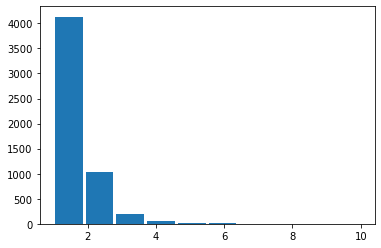

In [61]:
df_synset_counts = WORDNET_DF.groupby('synsetid')['senseid'].agg(['count'])
max_synset_members_count = df_synset_counts.max()[0]
plt.hist(df_synset_counts, bins=max_synset_members_count, rwidth=0.9)
plt.show() 

### Get final seed words for wordnet generation

In [62]:
words_list = WORDNET_DF['lemma'].unique().tolist() # drop duplicates
len(words_list)

5689

## Generate Sense Inventory

In [63]:
%%time

sense_inventory, logs = generate_sense_inventory(corpus=COHFIE_DF,
                                       words=words_list[:2],
                                       n_sentences=500,
                                       frac=None,
                                       window=5,
                                       random_state=118,
                                       debug=False,
                                       logs=True)

GENERATING SENSE INVENTORY

Total words: 2
Config:
    min_sentence_count to proceed with clustering: 20


Progress: 0.00%
Processing "matino"
    Collected sentences count: 691
    Encoding sentences...
    1-STEP...
Found 12 weak clusters. Purging...
recomputing centroids for trimmed cluster...
    2-STEP...
    3-STEP...
3
Progress: 50.00%
Processing "maayos"
    Collected sentences count: 1380
    Encoding sentences...
    1-STEP...
Found 9 weak clusters. Purging...
recomputing centroids for trimmed cluster...
    2-STEP...
    3-STEP...
3
Wall time: 16.7 s


### Save logs to file

In [64]:
with open('logs.pkl', 'wb') as handle:
    pickle.dump(logs, handle, protocol=3)

### Save sense inventory to file

In [65]:
sense_inventory.to_pickle("sense_inventory.pkl", protocol=3)

In [66]:
sv = pd.read_pickle("sense_inventory.pkl")
sv

,word,sense_id,sense_embedding,example_sentences,contextual_info,pos
0,matino,matino_0,"[-0.010973115, 0.011298004, 0.035818312, -0.02...","[lang yung maayos at matino no?, ko yung matin...","{'twitter': {'2021': 8}, 'bandera': {'2013': 1...",NN
1,matino,matino_1,"[0.0036590695, 0.039770428, 0.04998947, -0.013...","[Mukha lang ako matino HAHAHAA, halatang wala ...",{'twitter': {'2021': 10}},FW
2,matino,matino_2,"[0.009747508, -0.00621662, 0.042053748, -0.033...","[ng pelikula. Maganda at matino., kasama sa pe...","{'bandera': {'2014': 2, '2018': 2, '2015': 1, ...",VB
3,maayos,maayos_0,"[0.03358061, 0.021531925, 0.03476327, -0.06221...","[maayos naman., sana, maayos pong lahat., nang...","{'bandera': {'2016': 1}, 'abante': {'2020': 1}...",JJ
4,maayos,maayos_1,"[0.014303654, -0.04044015, -0.016788391, 0.008...",[Tatasahan pa sa ensayo kung maayos na ang rec...,"{'abante': {'2021': 2}, 'balita': {'2016': 1, ...",JJ
5,maayos,maayos_2,"[0.032500096, 0.010635486, 0.011949124, 0.0240...",[sumulong nang maayos at walang hadlang ang ka...,"{'google_books': {'2019': 3, '2020': 3, '2018'...",JJ
